In [ ]:
import pandas as pd
import json
import urllib.request
import matplotlib.pyplot as plt

## Process the reporting historic endpoint/dataset resource

In [2]:
datasets = ['article-4-direction-area', 'tree', 'tree-preservation-zone', 'listed-building-outline']

In [3]:
all_rows = []
last_rowid = 0

while True:
    if last_rowid == 0:
        # First batch: no filter
        url = "https://datasette.planning.data.gov.uk/performance/reporting_historic_endpoints.json?_shape=array&_size=max"
    else:
        # Subsequent batches: filter by rowid__gt
        url = f"https://datasette.planning.data.gov.uk/performance/reporting_historic_endpoints.json?_shape=array&_size=max&rowid__gt={last_rowid}"
    
    response = urllib.request.urlopen(url, timeout=120)
    rows = json.load(response)
    
    if not rows:
        break
    
    all_rows.extend(rows)
    last_rowid = rows[-1]['rowid']
    print(f"Fetched {len(all_rows)} rows...")
    
    if len(rows) < 1000:
        break

report_he = pd.DataFrame(all_rows)
print(f"Total: {len(report_he)} rows")


Fetched 1000 rows...
Fetched 2000 rows...
Fetched 3000 rows...
Fetched 4000 rows...
Fetched 5000 rows...
Fetched 6000 rows...
Fetched 7000 rows...
Fetched 8000 rows...
Fetched 9000 rows...
Fetched 10000 rows...
Fetched 11000 rows...
Fetched 12000 rows...
Fetched 13000 rows...
Fetched 14000 rows...
Fetched 15000 rows...
Fetched 16000 rows...
Fetched 17000 rows...
Fetched 18000 rows...
Fetched 19000 rows...
Fetched 20000 rows...
Fetched 21000 rows...
Fetched 22000 rows...
Fetched 23000 rows...
Fetched 24000 rows...
Fetched 25000 rows...
Fetched 25548 rows...
Total: 25548 rows


In [4]:
# Remove inactive endpoints and filter for only the 4 datasets we're interested in
report_he = report_he.loc[(report_he['dataset'].isin(datasets)) & (report_he['resource_end_date'] == '')]

In [5]:
report_he.loc[(report_he['dataset'] == 'article-4-direction-area') & (report_he['name'] == 'London Borough of Barking and Dagenham')]['resource'].item()

'e3eb3651fdb452b7396dbf901df1f54324971d25b71355e6a5f13309a69dfc81'

In [6]:
# Loop over and get the dataset_resource for each dataset, then concatenate into a single dataframe
dfs = []
for data in datasets:
    df = pd.read_csv(f'https://datasette.planning.data.gov.uk/{data}/dataset_resource.csv?_size=max')
    dfs.append(df)

data_resource = pd.concat(dfs)

In [7]:
data_resource.loc[data_resource['resource']=='e3eb3651fdb452b7396dbf901df1f54324971d25b71355e6a5f13309a69dfc81']

,rowid,end_date,entry_date,dataset,entity_count,entry_count,line_count,mime_type,internal_path,internal_mime_type,resource,start_date
43,44,NaN,NaN,article-4-direction-area,3.0,3,4,application/json;charset=ASCII,NaN,NaN,e3eb3651fdb452b7396dbf901df1f54324971d25b71355...,NaN


In [8]:
testing = pd.merge(report_he, data_resource[['resource', 'entity_count', 'entry_count']], on='resource')

# Groupby to get entity-count per LPA
dataset_resource_entity_count = testing.groupby(['dataset', 'name', 'organisation'])['entity_count'].sum().to_frame('dataset_resource_count').reset_index()

In [9]:
testing.loc[(testing['dataset'] == 'article-4-direction-area') & (testing['name'] == 'London Borough of Barking and Dagenham')]

,rowid,organisation,name,organisation_name,dataset,collection,pipeline,endpoint,endpoint_url,documentation_url,...,latest_status,latest_exception,resource,latest_log_entry_date,endpoint_entry_date,endpoint_end_date,resource_start_date,resource_end_date,entity_count,entry_count
4,6761,local-authority:BDG,London Borough of Barking and Dagenham,London Borough of Barking and Dagenham,article-4-direction-area,article-4-direction,article-4-direction-area,57b2b1e44cb711cb9bce7f25abf8fdfc75f8c40a9e4cd9...,https://services3.arcgis.com/lCzPKKaGs7lhrnrV/...,https://www.arcgis.com/home/item.html?id=b23bc...,...,200,,e3eb3651fdb452b7396dbf901df1f54324971d25b71355...,2026-03-24,2025-02-17,,2025-02-18,,3.0,3


---

## Process the platform data

In [10]:
organisation = pd.read_csv('https://datasette.planning.data.gov.uk/digital-land/organisation.csv?_labels=on&_size=max')

organisation = organisation[['entity', 'organisation', 'name']].rename(columns={'entity':'organisation-entity', 
                                                                                'name':'organisation-name',
                                                                                'organisation':'organisation-code'})

In [12]:
dfs = []

for data in datasets:
    url = f'https://files.planning.data.gov.uk/dataset/{data}.csv'
    df = pd.read_csv(url)
    dfs.append(df)

platform_data = pd.concat(dfs)

/var/folders/ff/zpylthrn3877kx4h8lxvsvjm0000gn/T/ipykernel_24654/3044584250.py:5: DtypeWarning: Columns (14,16,17,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)
/var/folders/ff/zpylthrn3877kx4h8lxvsvjm0000gn/T/ipykernel_24654/3044584250.py:5: DtypeWarning: Columns (15,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)
/var/folders/ff/zpylthrn3877kx4h8lxvsvjm0000gn/T/ipykernel_24654/3044584250.py:5: DtypeWarning: Columns (14,15,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [13]:
platform_data = pd.merge(platform_data, organisation, on='organisation-entity', how='left')

In [14]:
platform_entity_count = platform_data.groupby(['dataset', 'organisation-name', 'organisation-code']).size().to_frame('platform_count').reset_index()\
                                     .rename(columns={'organisation-name':'name', 'organisation-code':'organisation'})

In [15]:
platform_entity_count

,dataset,name,organisation,platform_count
0,article-4-direction-area,Adur District Council,local-authority:ADU,9
1,article-4-direction-area,Ashford Borough Council,local-authority:ASF,75
2,article-4-direction-area,Birmingham City Council,local-authority:BIR,13
3,article-4-direction-area,Bristol City Council,local-authority:BST,16
4,article-4-direction-area,Broadland District Council,local-authority:BRO,28
...,...,...,...,...
278,tree-preservation-zone,Tewkesbury Borough Council,local-authority:TEW,556
279,tree-preservation-zone,Thanet District Council,local-authority:THA,677
280,tree-preservation-zone,Torbay Council,local-authority:TOB,834
281,tree-preservation-zone,West Berkshire Council,local-authority:WBK,1115


---

## Merge together and compare

In [17]:
testing = pd.merge(platform_entity_count, dataset_resource_entity_count, on=['dataset', 'name', 'organisation'], how='outer')

In [27]:
testing

,dataset,name,organisation,platform_count,dataset_resource_count,match
0,article-4-direction-area,Adur District Council,local-authority:ADU,9,NaN,mismatch
1,article-4-direction-area,Ashford Borough Council,local-authority:ASF,75,56.0,mismatch
2,article-4-direction-area,Birmingham City Council,local-authority:BIR,13,12.0,mismatch
3,article-4-direction-area,Bristol City Council,local-authority:BST,16,NaN,mismatch
4,article-4-direction-area,Broadland District Council,local-authority:BRO,28,NaN,mismatch
...,...,...,...,...,...,...
278,tree-preservation-zone,Tewkesbury Borough Council,local-authority:TEW,556,445.0,mismatch
279,tree-preservation-zone,Thanet District Council,local-authority:THA,677,677.0,match
280,tree-preservation-zone,Torbay Council,local-authority:TOB,834,728.0,mismatch
281,tree-preservation-zone,West Berkshire Council,local-authority:WBK,1115,923.0,mismatch


In [ ]:
testing['match'] = testing.apply(lambda row: 'match' if row['platform_count'] == row['dataset_resource_count'] else 'mismatch', axis=1)

In [28]:
testing['match'].value_counts()

match
mismatch    230
match        53
Name: count, dtype: int64

In [21]:
testing.loc[testing['match'] == 'mismatch']

,dataset,name,organisation,platform_count,dataset_resource_count,match
0,article-4-direction-area,Adur District Council,local-authority:ADU,9,NaN,mismatch
1,article-4-direction-area,Ashford Borough Council,local-authority:ASF,75,56.0,mismatch
2,article-4-direction-area,Birmingham City Council,local-authority:BIR,13,12.0,mismatch
3,article-4-direction-area,Bristol City Council,local-authority:BST,16,NaN,mismatch
4,article-4-direction-area,Broadland District Council,local-authority:BRO,28,NaN,mismatch
...,...,...,...,...,...,...
277,tree-preservation-zone,Tandridge District Council,local-authority:TAN,885,NaN,mismatch
278,tree-preservation-zone,Tewkesbury Borough Council,local-authority:TEW,556,445.0,mismatch
280,tree-preservation-zone,Torbay Council,local-authority:TOB,834,728.0,mismatch
281,tree-preservation-zone,West Berkshire Council,local-authority:WBK,1115,923.0,mismatch


In [22]:
testing.loc[testing['name'] == 'London Borough of Barking and Dagenham']

,dataset,name,organisation,platform_count,dataset_resource_count,match
38,article-4-direction-area,London Borough of Barking and Dagenham,local-authority:BDG,3,3.0,match
118,listed-building-outline,London Borough of Barking and Dagenham,local-authority:BDG,48,NaN,mismatch


In [26]:
testing.loc[testing['dataset'] == 'tree']

,dataset,name,organisation,platform_count,dataset_resource_count,match
164,tree,Ashford Borough Council,local-authority:ASF,1224,0.0,mismatch
165,tree,Basildon Borough Council,local-authority:BAI,549,NaN,mismatch
166,tree,Bristol City Council,local-authority:BST,4961,4940.0,mismatch
167,tree,Buckinghamshire Council,local-authority:BUC,7591,591.0,mismatch
168,tree,Castle Point Borough Council,local-authority:CAS,1629,0.0,mismatch
169,tree,City of Westminster,local-authority:WSM,4286,0.0,mismatch
170,tree,Dartford Borough Council,local-authority:DAR,1202,0.0,mismatch
171,tree,Doncaster Metropolitan Borough Council,local-authority:DNC,2832,0.0,mismatch
172,tree,Dover District Council,local-authority:DOV,1365,0.0,mismatch
173,tree,East Cambridgeshire District Council,local-authority:ECA,2557,0.0,mismatch


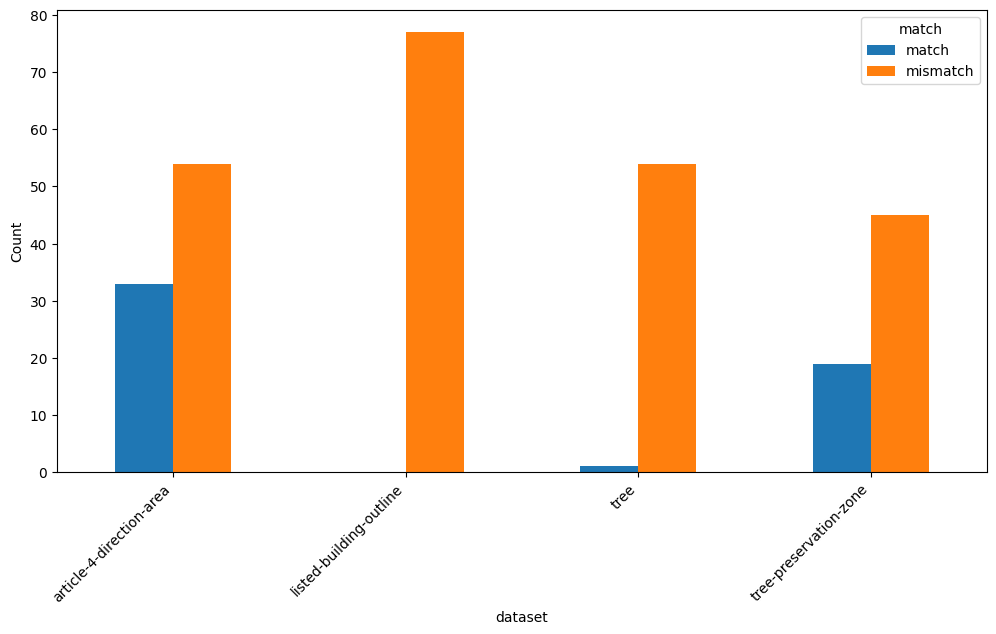

In [25]:
f, ax = plt.subplots(figsize=(12, 6))

data = testing.groupby(['dataset', 'match']).size().unstack(fill_value=0)

data.plot(kind='bar', ax=ax)
plt.xticks(rotation=45, ha='right')

ax.set_ylabel('Count')

plt.show()

---
## Randomly check resources

Take ten resources at random and investigate them to get a sample of the problems.

Some things to check for each:

1. the entity_count of the platform vs the dataset_resource entity_count. If they are equal then all is good
2. if they are not equal then download the transformed_resource (I can probably give you the link structure to follow) and download the entities  from the platform. Get the entities that aren’t in the resource but are on the platform. you can then look at these entities to check the history of what’s going on.
3. check the entity_count on the dataset_resource is equal to the entity_count in the transformed resource. This wil tell us if there’s a processing issue

the link to transformed resources wil be something like:
files.planning.data.gov.uk/<collection>-collection/transformed/<dataset>/<resource_hash>.csv

In [41]:
# Get a random sample of 10 resources
sample_df = report_he.sample(n=10, random_state=42)
sample_resources = sample_df['resource'].tolist()

sample_resources

['47b2c02399036050fe507e4b90ee532f25293b19f7cec9fb308336e625f7109b',
 '3081bb2dec818694e2a6eaccd39ad37abc7dca39131dd8b085d413931ee21109',
 'bb6a8eb7e6f4720030aec3bd5fdff525700d8ae045cd7b32fd08f4c8614efc5e',
 '6eb49d0579ac5162126f793800ead81a74761b880e4066fc623a01ec72678952',
 '5837666a86b654bdf27164f2fa5bdc6c74552efccda5c4ff982356df89fa1787',
 '8b88687d996f7b9bbcfae4f4ba7c515f55eef34212a0064eb922891d3c99a97e',
 'd632df6f6b49074036d830502a8f22df6b3e75593d9a8cd783d4ccf33d6dd67a',
 'dd14d735a5cc249c6a3c4751e134c2040a83e58aa0c29475faed0825b54c2927',
 'ae9aa5602c72b8a76da0eac063f7190e9211fd198244e244c89d65b41306a192',
 '85e3264ae354c8701d3147d13c54a4bc6b5edbefebfe6add3cf010243303ef95']

In [63]:
sample_df

,rowid,organisation,name,organisation_name,dataset,collection,pipeline,endpoint,endpoint_url,documentation_url,licence,latest_status,latest_exception,resource,latest_log_entry_date,endpoint_entry_date,endpoint_end_date,resource_start_date,resource_end_date
14854,14855,local-authority:GLO,Gloucester City Council,Gloucester City Council,listed-building-outline,listed-building,listed-building-outline,f569cf738abb48f8d9d2bda008b5e27716877dd84a22fa...,https://gcty.dynamicmaps.co.uk:8443/geoserver/...,https://www.gloucester.gov.uk/planning-develop...,ogl3,200,,47b2c02399036050fe507e4b90ee532f25293b19f7cec9...,2026-03-24,2024-08-13,,2024-09-21,
14865,14866,local-authority:GLO,Gloucester City Council,Gloucester City Council,tree,tree-preservation-order,tree,599237e24ea953f431090df305657e05d78d64e6e33adc...,https://gcty.dynamicmaps.co.uk:8443/geoserver/...,https://www.gloucester.gov.uk/environment-wast...,ogl3,200,,3081bb2dec818694e2a6eaccd39ad37abc7dca39131dd8...,2026-03-24,2024-08-12,,2024-08-13,
20609,20610,local-authority:ROS,Rossendale Borough Council,Rossendale Borough Council,listed-building-outline,listed-building,listed-building-outline,3da95e36b0c049a66afc06990be03fb14cf070a24ae89f...,https://www.rossendale.gov.uk/downloads/file/1...,https://www.rossendale.gov.uk/heritage/heritag...,ogl3,200,,bb6a8eb7e6f4720030aec3bd5fdff525700d8ae045cd7b...,2026-03-24,2025-12-01,,2025-12-02,
17019,17020,local-authority:LCE,Leicester City Council,Leicester City Council,tree-preservation-zone,tree-preservation-order,tree-preservation-zone,381e46f1261f1edd7d67238973f01c8021cf675f65f493...,https://geoserver.leicester.gov.uk/geoserver/O...,https://data.leicester.gov.uk/explore/?sort=mo...,ogl3,200,,6eb49d0579ac5162126f793800ead81a74761b880e4066...,2026-03-24,2025-09-29,,2026-03-24,
24480,24481,local-authority:WFT,London Borough of Waltham Forest,London Borough of Waltham Forest,tree-preservation-zone,tree-preservation-order,tree-preservation-zone,c18514d51a4072b1fa0eceb0e390e65555bfcc93135b37...,https://walthamforest.statmap.co.uk/map/wfs.sv...,https://www.walthamforest.gov.uk/neighbourhood...,ogl3,200,,5837666a86b654bdf27164f2fa5bdc6c74552efccda5c4...,2026-03-24,2026-01-20,,2026-01-21,
22220,22221,local-authority:TAN,Tandridge District Council,Tandridge District Council,article-4-direction-area,article-4-direction,article-4-direction-area,51020cd616333d91260a1bad500167d9cc02e85fb50c19...,https://services8.arcgis.com/DOopK66xzdr2Avop/...,https://tdcmaps.tandridge.gov.uk/odp_data/odp_...,ogl3,200,,8b88687d996f7b9bbcfae4f4ba7c515f55eef34212a006...,2026-03-24,2026-02-20,,2026-02-21,
14352,14353,local-authority:EPS,Epsom and Ewell Borough Council,Epsom and Ewell Borough Council,listed-building-outline,listed-building,listed-building-outline,b64e3b0edc13c75c0a21a459c13c7c9c6eb89e0785885c...,https://maps.epsom-ewell.gov.uk/getows.ashx?ma...,https://www.epsom-ewell.gov.uk/residents/plann...,,200,,d632df6f6b49074036d830502a8f22df6b3e75593d9a8c...,2026-03-24,2023-12-18,,2026-02-14,
6787,6788,local-authority:BDG,London Borough of Barking and Dagenham,London Borough of Barking and Dagenham,listed-building-outline,listed-building,listed-building-outline,6a183d1c8b8505b27532c8335137139be5b8cdb97f8c2a...,https://services3.arcgis.com/lCzPKKaGs7lhrnrV/...,https://www.arcgis.com/home/item.html?id=8421a...,ogl3,200,,dd14d735a5cc249c6a3c4751e134c2040a83e58aa0c294...,2026-03-24,2025-02-18,,2025-02-19,
22824,22825,local-authority:TWH,London Borough of Tower Hamlets,London Borough of Tower Hamlets,tree,tree-preservation-order,tree,eaceade72cd00741743fba9921fb2ef764ed3363f882f4...,https://services1.arcgis.com/KZuCGRSe2K5BiG1Z/...,https://www.towerhamlets.gov.uk/lgnl/planning_...,ogl3,200,,ae9aa5602c72b8a76da0eac063f7190e9211fd198244e2...,2026-03-24,2025-01-02,,2025-12-02,
24767,24768,local-authority:WOX,West Oxfordshire District Council,West Oxfordshire District Council,article-4-direction-area,article-4-direction,article-4-direction-area,5a762b7a74f89910bb2f3afabf0641

In [44]:
# Check the entity_counts for these resources in the dataset_resource table
data_resource.loc[data_resource['resource'].isin(sample_resources)].head(10)

,rowid,end_date,entry_date,dataset,entity_count,entry_count,line_count,mime_type,internal_path,internal_mime_type,resource,start_date
407,408,NaN,NaN,article-4-direction-area,84.0,84,85,application/json;charset=ASCII,NaN,NaN,85e3264ae354c8701d3147d13c54a4bc6b5edbefebfe6a...,NaN
37,38,NaN,NaN,tree,NaN,1358,1359,application/xml;charset=ASCII,NaN,NaN,3081bb2dec818694e2a6eaccd39ad37abc7dca39131dd8...,NaN
744,745,NaN,NaN,tree,NaN,1677,1678,application/json;charset=ASCII,NaN,NaN,ae9aa5602c72b8a76da0eac063f7190e9211fd198244e2...,NaN
972,973,NaN,NaN,tree-preservation-zone,217.0,217,218,application/xml;charset=ASCII,NaN,NaN,5837666a86b654bdf27164f2fa5bdc6c74552efccda5c4...,NaN
159,160,NaN,NaN,listed-building-outline,NaN,278,279,text/csv;charset=ASCII,NaN,NaN,bb6a8eb7e6f4720030aec3bd5fdff525700d8ae045cd7b...,NaN


Only 5 out of the 10 resources are showing.

| Resource | Dataset | LPA | dataset_resource entity_count | platform entity_count | transformed resource entity_count |
| ----- | ------ | ----- | ------ | ---- | ---- |
| 47b2c02399036050fe507e4b90ee532f25293b19f7cec9fb308336e625f7109b | LBO | Gloucester City | Missing | 486 | 486
| 6eb49d0579ac5162126f793800ead81a74761b880e4066fc623a01ec72678952 | TPZ | Leicester City | Missing | 146 | 146 |
| 8b88687d996f7b9bbcfae4f4ba7c515f55eef34212a0064eb922891d3c99a97e | A4D | Tandridge | Missing | 50 | 50
| d632df6f6b49074036d830502a8f22df6b3e75593d9a8cd783d4ccf33d6dd67a | LBO | Epsom and Ewell | Missing | 272 | 272
| dd14d735a5cc249c6a3c4751e134c2040a83e58aa0c29475faed0825b54c2927 | LBO | Barking and Dagenham | Missing | 48 | 48
| 3081bb2dec818694e2a6eaccd39ad37abc7dca39131dd8b085d413931ee21109 | Tree | Gloucester City | No entity recorded | 1358 | 1358
| ae9aa5602c72b8a76da0eac063f7190e9211fd198244e244c89d65b41306a192 | Tree | Tower Hamlets | No entity recorded | 1769 | 1677
| bb6a8eb7e6f4720030aec3bd5fdff525700d8ae045cd7b32fd08f4c8614efc5e | LBO | Rossendale | No entity recorded | 278 | 278
| 85e3264ae354c8701d3147d13c54a4bc6b5edbefebfe6add3cf010243303ef95 | A4D | West Oxfordshire | 84 | 84 | n/a |
| 5837666a86b654bdf27164f2fa5bdc6c74552efccda5c4ff982356df89fa1787 | TPZ | Waltham Forest | 217 | 217 | n/a |

Let's first investigate the platform entity counts now.

https://files.planning.data.gov.uk/listed-building-collection/transformed/listed-building-outline/6df5bd01605beb5eec759d8b451d5a7a699b65edb6af10baaea10bab85ece59c.csv

In [65]:
platform_entity_count

,dataset,name,organisation,platform_count
0,article-4-direction-area,Adur District Council,local-authority:ADU,9
1,article-4-direction-area,Ashford Borough Council,local-authority:ASF,75
2,article-4-direction-area,Birmingham City Council,local-authority:BIR,13
3,article-4-direction-area,Bristol City Council,local-authority:BST,16
4,article-4-direction-area,Broadland District Council,local-authority:BRO,28
...,...,...,...,...
278,tree-preservation-zone,Tewkesbury Borough Council,local-authority:TEW,556
279,tree-preservation-zone,Thanet District Council,local-authority:THA,677
280,tree-preservation-zone,Torbay Council,local-authority:TOB,834
281,tree-preservation-zone,West Berkshire Council,local-authority:WBK,1115


In [66]:
result = sample_df.merge(
    platform_entity_count,
    on=['name', 'dataset'], how='inner')

result[['collection', 'dataset', 'resource', 'platform_count']]

,collection,dataset,resource,platform_count
0,listed-building,listed-building-outline,47b2c02399036050fe507e4b90ee532f25293b19f7cec9...,486
1,tree-preservation-order,tree,3081bb2dec818694e2a6eaccd39ad37abc7dca39131dd8...,1358
2,listed-building,listed-building-outline,bb6a8eb7e6f4720030aec3bd5fdff525700d8ae045cd7b...,278
3,tree-preservation-order,tree-preservation-zone,6eb49d0579ac5162126f793800ead81a74761b880e4066...,146
4,tree-preservation-order,tree-preservation-zone,5837666a86b654bdf27164f2fa5bdc6c74552efccda5c4...,217
5,article-4-direction,article-4-direction-area,8b88687d996f7b9bbcfae4f4ba7c515f55eef34212a006...,50
6,listed-building,listed-building-outline,d632df6f6b49074036d830502a8f22df6b3e75593d9a8c...,272
7,listed-building,listed-building-outline,dd14d735a5cc249c6a3c4751e134c2040a83e58aa0c294...,48
8,tree-preservation-order,tree,ae9aa5602c72b8a76da0eac063f7190e9211fd198244e2...,1769
9,article-4-direction,article-4-direction-area,85e3264ae354c8701d3147d13c54a4bc6b5edbefebfe6a...,84


So the two resources that had entities - 85e... and 583... - matches the platform data. But what's happened to the other 8?

Let's use the link to transformed resources:
files.planning.data.gov.uk/<collection>-collection/transformed/<dataset>/<resource_hash>.csv

In [70]:
for idx, rows in result.iterrows():
    collection = rows['collection']
    dataset = rows['dataset']
    resource = rows['resource']
    
    url = f"http://files.planning.data.gov.uk/{collection}-collection/transformed/{dataset}/{resource}.csv"

    df = pd.read_csv(url)

    unique_entities = df['entity'].nunique()
    print(f"Resource: {resource}, Unique Entities: {unique_entities}")


Resource: 47b2c02399036050fe507e4b90ee532f25293b19f7cec9fb308336e625f7109b, Unique Entities: 486
Resource: 3081bb2dec818694e2a6eaccd39ad37abc7dca39131dd8b085d413931ee21109, Unique Entities: 1358
Resource: bb6a8eb7e6f4720030aec3bd5fdff525700d8ae045cd7b32fd08f4c8614efc5e, Unique Entities: 278
Resource: 6eb49d0579ac5162126f793800ead81a74761b880e4066fc623a01ec72678952, Unique Entities: 146
Resource: 5837666a86b654bdf27164f2fa5bdc6c74552efccda5c4ff982356df89fa1787, Unique Entities: 217
Resource: 8b88687d996f7b9bbcfae4f4ba7c515f55eef34212a0064eb922891d3c99a97e, Unique Entities: 50
Resource: d632df6f6b49074036d830502a8f22df6b3e75593d9a8cd783d4ccf33d6dd67a, Unique Entities: 272
Resource: dd14d735a5cc249c6a3c4751e134c2040a83e58aa0c29475faed0825b54c2927, Unique Entities: 48
Resource: ae9aa5602c72b8a76da0eac063f7190e9211fd198244e244c89d65b41306a192, Unique Entities: 1677
Resource: 85e3264ae354c8701d3147d13c54a4bc6b5edbefebfe6add3cf010243303ef95, Unique Entities: 84


---
## How many more matches do we get using transformed resources over the dataset resource?

In [72]:
report_he.head()

,rowid,organisation,name,organisation_name,dataset,collection,pipeline,endpoint,endpoint_url,documentation_url,licence,latest_status,latest_exception,resource,latest_log_entry_date,endpoint_entry_date,endpoint_end_date,resource_start_date,resource_end_date
748,749,government-organisation:D1342,"Ministry of Housing, Communities & Local Gover...","Ministry of Housing, Communities & Local Gover...",listed-building-outline,listed-building,listed-building-outline,4bd57a7a9d880048f310229d123942a33a338dfd01807f...,https://files.planning.data.gov.uk/reporting/l...,https://planning.data.gov.uk,ogl3,200,,c89557a7ac5c73bd83c153912d188848719555e1ddb8d8...,2026-03-24,2026-03-18,,2026-03-19,
6323,6324,local-authority:ADU,Adur District Council,Adur District Council,article-4-direction-area,article-4-direction,article-4-direction-area,0f326a65974b3720aa65c70949a2b4056cfcb79543d706...,https://adur-worthing.statmap.co.uk/map/webser...,https://www.adur-worthing.gov.uk/planning/arti...,ogl3,200,,2662361965312f297c799738449d67655fe42a76d10f59...,2026-03-23,2025-11-20,,2025-12-01,
6354,6355,local-authority:ADU,Adur District Council,Adur District Council,listed-building-outline,listed-building,listed-building-outline,73b1921bcf4e991c9f67e51781a2a2d85b4a65260bd9bf...,https://adur-worthing.statmap.co.uk/map/webser...,https://www.adur-worthing.gov.uk/planning-poli...,ogl3,200,,1fdec747f46dd81d17199c02a8272bc1ea36b2ce2515c9...,2026-03-24,2026-01-19,,2026-02-27,
6455,6456,local-authority:ASF,Ashford Borough Council,Ashford Borough Council,article-4-direction-area,article-4-direction,article-4-direction-area,5f1a05d6c7c32c81657d86e8d6c55e3db9ec0824ea191f...,https://www.ashford.gov.uk/media/vlymbjea/arti...,https://www.ashford.gov.uk/transparency/open-d...,ogl3,200,,04804fda473cfa31e82700d842c85a23a19c4b5e984831...,2026-03-24,2025-10-23,,2025-12-31,
6511,6512,local-authority:ASF,Ashford Borough Council,Ashford Borough Council,listed-building-outline,listed-building,listed-building-outline,11f92a65f2c5963326433aef82d6f9a66e2f5031bd5f48...,https://www.ashford.gov.uk/media/qxgbarwo/list...,https://www.ashford.gov.uk/transparency/open-d...,ogl3,200,,3f3fca9a1e7b2851ff89136f9e97e30368962f4d71b50c...,2026-03-24,2025-09-12,,2025-09-13,


In [73]:
transformed = []

for idx, rows in report_he.iterrows():
    organisation = rows['organisation']
    name = rows['name']
    collection = rows['collection']
    dataset = rows['dataset']
    resource = rows['resource']
    
    url = f"http://files.planning.data.gov.uk/{collection}-collection/transformed/{dataset}/{resource}.csv"

    df = pd.read_csv(url)

    unique_entities = df['entity'].nunique()

    transformed.append({
        'organisation': organisation,
        'name': name,
        'collection': collection,
        'dataset': dataset,
        'resource': resource,
        'unique_entities': unique_entities
    })
    #print(f"Resource: {resource}, Unique Entities: {unique_entities}")

In [ ]:
# Convert to dataframe
transformed_resources = pd.DataFrame(transformed)

# Groupby to get entity-count per LPA
transformed_resources_groupby = transformed_resources.groupby(['dataset', 'name', 'organisation'])['unique_entities'].sum().to_frame('transformed_resources_count').reset_index()#.unstack(fill_value=0)

In [ ]:
# Merge with platform_entity_count to compare counts
testing_2 = pd.merge(platform_entity_count, transformed_resources_groupby, on=['dataset', 'name', 'organisation'], how='outer')
testing_2['match'] = testing_2.apply(lambda row: 'match' if row['platform_count'] == row['transformed_resources_count'] else 'mismatch', axis=1)

In [ ]:
testing_2['match'].value_counts()

## This is better than the dataset_resource counts, but there are still some mismatches

match
match       180
mismatch    104
Name: count, dtype: int64

In [90]:
testing_2.loc[testing_2['match'] == 'mismatch']

,dataset,name,organisation,platform_count,transformed_resources_count,match
1,article-4-direction-area,Ashford Borough Council,local-authority:ASF,75.0,56.0,mismatch
2,article-4-direction-area,Birmingham City Council,local-authority:BIR,13.0,12.0,mismatch
5,article-4-direction-area,Buckinghamshire Council,local-authority:BUC,389.0,467.0,mismatch
8,article-4-direction-area,Canterbury City Council,local-authority:CAT,463.0,461.0,mismatch
9,article-4-direction-area,Castle Point Borough Council,local-authority:CAS,4.0,NaN,mismatch
...,...,...,...,...,...,...
273,tree-preservation-zone,South Staffordshire Council,local-authority:SST,2602.0,1300.0,mismatch
279,tree-preservation-zone,Tewkesbury Borough Council,local-authority:TEW,556.0,445.0,mismatch
281,tree-preservation-zone,Torbay Council,local-authority:TOB,834.0,728.0,mismatch
282,tree-preservation-zone,West Berkshire Council,local-authority:WBK,1115.0,923.0,mismatch


---
## Merge all 3 datasets together to compare counts
The dataset_resource, transformed resource, and the platform data

In [93]:
### Merge all three together to compare counts
final_merge = pd.merge(testing_2, dataset_resource_entity_count, on=['dataset', 'name', 'organisation'], how='outer')

In [95]:
final_merge = final_merge.rename(columns={'match': 'platform_vs_transformed_match'})

final_merge['platform_vs_dataset_resource_match'] = final_merge.apply(lambda row: 'match' if row['platform_count'] == row['dataset_resource_count'] else 'mismatch', axis=1)
final_merge['transformed_vs_dataset_resource_match'] = final_merge.apply(lambda row: 'match' if row['transformed_resources_count'] == row['dataset_resource_count'] else 'mismatch', axis=1)

In [102]:
# Show mismatches between transformed resources and dataset_resource counts
trans_dr_mismatch = final_merge.loc[final_merge['transformed_vs_dataset_resource_match'] == 'mismatch'][['dataset', 'name', 'organisation', 'transformed_resources_count', 'dataset_resource_count', 'transformed_vs_dataset_resource_match']]
trans_dr_mismatch

,dataset,name,organisation,transformed_resources_count,dataset_resource_count,transformed_vs_dataset_resource_match
0,article-4-direction-area,Adur District Council,local-authority:ADU,9.0,NaN,mismatch
3,article-4-direction-area,Bristol City Council,local-authority:BST,16.0,NaN,mismatch
4,article-4-direction-area,Broadland District Council,local-authority:BRO,28.0,NaN,mismatch
5,article-4-direction-area,Buckinghamshire Council,local-authority:BUC,467.0,256.0,mismatch
6,article-4-direction-area,Calderdale Metropolitan Borough Council,local-authority:CLD,8.0,NaN,mismatch
...,...,...,...,...,...,...
270,tree-preservation-zone,South Cambridgeshire District Council,local-authority:SCA,2210.0,NaN,mismatch
273,tree-preservation-zone,South Staffordshire Council,local-authority:SST,1300.0,NaN,mismatch
275,tree-preservation-zone,St Albans City and District Council,local-authority:SAL,544.0,NaN,mismatch
278,tree-preservation-zone,Tandridge District Council,local-authority:TAN,885.0,NaN,mismatch


In [104]:
trans_dr_mismatch.sample(n=25, random_state=42)

,dataset,name,organisation,transformed_resources_count,dataset_resource_count,transformed_vs_dataset_resource_match
57,article-4-direction-area,North Norfolk District Council,local-authority:NNO,42.0,NaN,mismatch
214,tree,Tandridge District Council,local-authority:TAN,1678.0,0.0,mismatch
178,tree,Gloucester City Council,local-authority:GLO,1358.0,0.0,mismatch
113,listed-building-outline,Hart District Council,local-authority:HAT,1954.0,0.0,mismatch
97,listed-building-outline,Central Bedfordshire Council,local-authority:CBF,1918.0,NaN,mismatch
275,tree-preservation-zone,St Albans City and District Council,local-authority:SAL,544.0,NaN,mismatch
77,article-4-direction-area,Stoke-on-Trent City Council,local-authority:STE,27.0,NaN,mismatch
227,tree-preservation-zone,Castle Point Borough Council,local-authority:CAS,179.0,NaN,mismatch
13,article-4-direction-area,Cotswold District Council,local-authority:COT,22.0,NaN,mismatch
138,listed-building-outline,North Tyneside Council,local-authority:NTY,221.0,0.0,mismatch
